<a href="https://colab.research.google.com/github/faizaan0619/MachineLearning/blob/main/Unsupervised/MNIST_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

In [ ]:
X = mnist.data[:1000]
y = mnist.target[:1000]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pca = PCA(n_components=50)

In [ ]:
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
print(X_train.shape)
print(X_train_pca.shape)

(800, 784)
(800, 50)


/tmp/ipykernel_1038/1109855965.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], cmap="plasma")


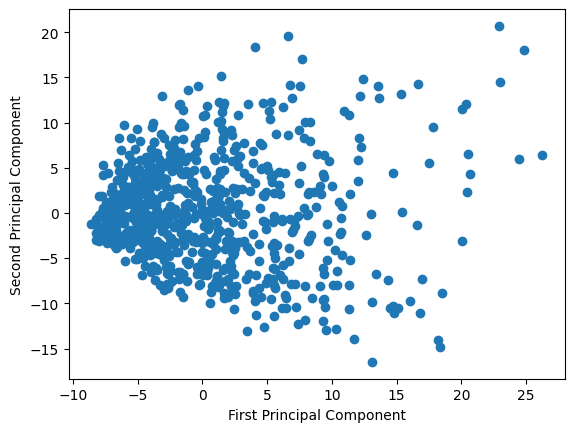

In [ ]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], cmap="plasma")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
model = SVC()

In [ ]:
model.fit(X_train_pca, y_train)
# model.fit(X_train_scaled, y_train)

SVC()

In [ ]:
y_pred = model.predict(X_test_pca)
# y_pred = model.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.875

without PCA, Accuracy = 83%
with PCA, Accuracy = 87.5%

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.83      0.95      0.88        20
           2       0.71      1.00      0.83        22
           3       1.00      0.88      0.94        26
           4       0.87      0.87      0.87        15
           5       0.84      0.94      0.89        17
           6       1.00      0.83      0.90        23
           7       1.00      0.75      0.86        24
           8       0.92      0.85      0.88        13
           9       0.84      0.76      0.80        21

    accuracy                           0.88       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.88      0.88       200



In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)

(1797, 64)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print(X_tsne.shape)

(1797, 2)


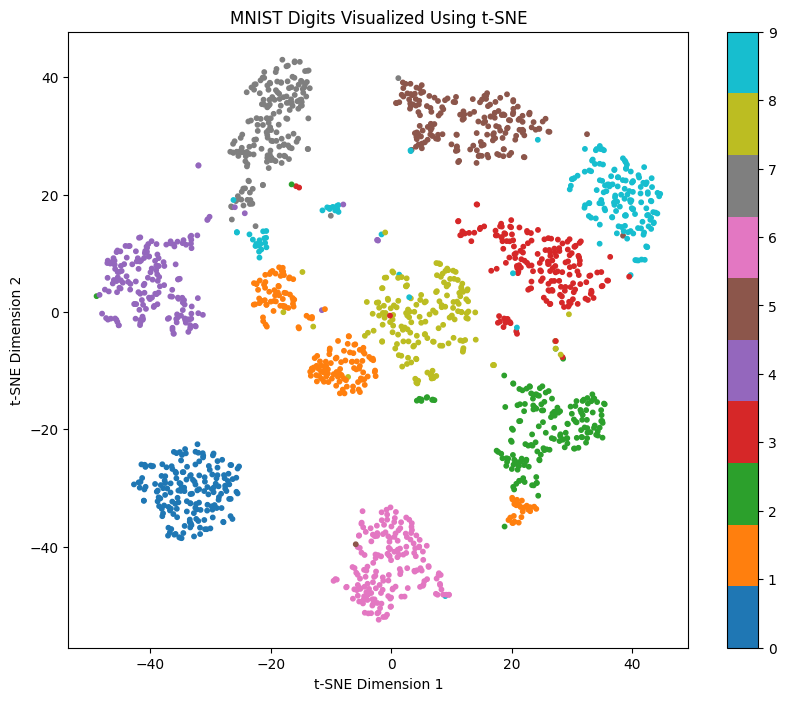

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=10
)

plt.colorbar()

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("MNIST Digits Visualized Using t-SNE")

plt.show()